<a href="https://colab.research.google.com/github/Cosider24/machine-learning-fundamentals/blob/main/02-knn-sklearn-breast-cancer/Breast_Cancer_Wisconsin.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Работа 2_1

Цель работы:
Познакомиться с алгоритмом k-ближайших соседей (KNN), изучить его работу на реальных данных и научиться оценивать качество классификации.

Датасет:
В ноутбуке используется датасет Breast Cancer Wisconsin (Диагностика рака молочной железы).

Содержит признаки клеток опухоли (30 числовых признаков, таких как площадь, радиус и т.д.).

Признаки: 30 числовых характеристик клеток опухоли (например, размер, форма, текстура).

Целевая переменная: diagnosis

M — злокачественная опухоль (Malignant)

B — доброкачественная опухоль (Benign)

##Шаг 1. Импорт библиотек

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

Пояснение:

pandas и numpy — для работы с таблицами и массивами

matplotlib и seaborn — для графиков

train_test_split — делим данные на тренировочные и тестовые

KNeighborsClassifier — готовый KNN

accuracy_score и confusion_matrix — проверка качества модели

##Шаг 2. Загрузка и подготовка данных

2.1 Считайте данные с помощью функции pd.read_csv() и ссылки на датасет: https://raw.githubusercontent.com/melwinlobo18/K-Nearest-Neighbors/master/Dataset/data.csv

In [ ]:
df = pd.read_csv("https://raw.githubusercontent.com/melwinlobo18/K-Nearest-Neighbors/master/Dataset/data.csv")

2.2. Посмотрите на первые строки:

In [ ]:
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


2.3. Посмотрите размер и типы данных:

In [ ]:
df.shape

(569, 33)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [ ]:
df.describe()

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,0.0
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,NaN
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,NaN
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,NaN
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,NaN
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,NaN
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,NaN
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,NaN


Пояснение:

head() — первые 5 строк

shape — сколько строк и столбцов

info() — типы данных и пропущенные значения

describe() — статистика по числовым столбцам

##Шаг 3. Подготовка данных

3.1. Преобразуем метки diagnosis в числа:

In [ ]:
df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})
df['diagnosis'].head()

,diagnosis
0,1
1,1
2,1
3,1
4,1


Посмотрите на датафрейм после преобразования, что изменилось?

M (Malignant) → 1

B (Benign) → 0

Зачем: алгоритмы ML работают с числами, а не с буквами.

3.2. Удалите ненужные столбцы (например, ID)  с помощью df = df.drop(['name', 'name'], axis=1)

In [ ]:
df = df.drop(['id', 'Unnamed: 32'],axis = 1)
df.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


3.3 Выполните проверку на пропуски

In [ ]:
df.isnull().sum()

,0
diagnosis,0
radius_mean,0
texture_mean,0
perimeter_mean,0
area_mean,0
smoothness_mean,0
compactness_mean,0
concavity_mean,0
concave points_mean,0
symmetry_mean,0


##Шаг 4. Исследование и визуализация данных

4.1. Посчитайте количество объектов каждого класса

In [ ]:
class_counts = df['diagnosis'].value_counts()
print(class_counts)

diagnosis
0    357
1    212
Name: count, dtype: int64


4.2 Постройте pair plot по 2-3 признакам

sns.pairplot(df, vars=['name','name','name'], hue='diagnosis')
plt.show()

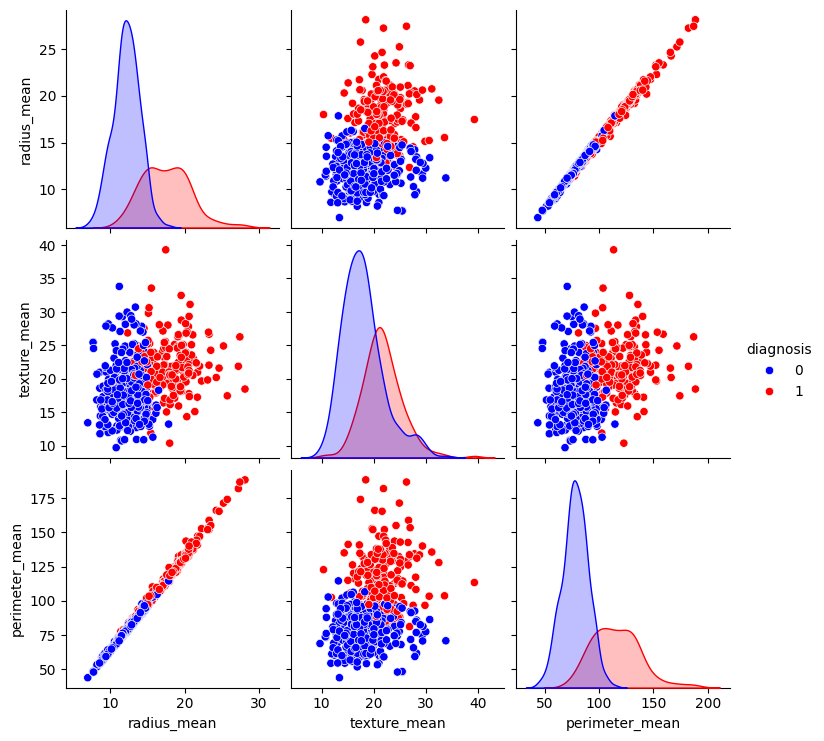

In [ ]:
sns.pairplot(df, vars=['radius_mean', 'texture_mean', 'perimeter_mean'],
             hue='diagnosis', palette=['blue', 'red'])
plt.show()

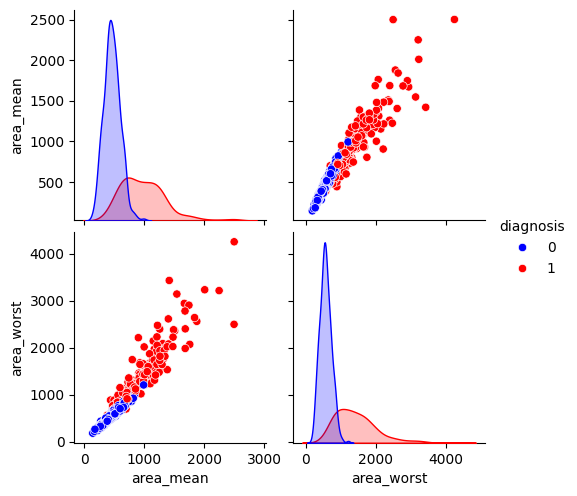

In [ ]:
sns.pairplot(df, vars=['area_mean', 'area_worst'],
             hue='diagnosis', palette=['blue', 'red'])
plt.show()

Pairplot показывает, как объекты разных классов разделяются по выбранным признакам

##Шаг 5. Разделение на тренировочную и тестовую выборку

5.1 Выполните разделение данных на тестовую и тренировочную выборку, объясните для чего это нужно

In [ ]:
X = df.drop('diagnosis', axis=1)
y = df['diagnosis']

print("Размер X (признаки):", X.shape)
print("Размер y (целевая переменная):", y.shape)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)
print("Обучающая выборка (признаки):", X_train.shape)
print("Обучающая выборка (цели):", y_train.shape)
print("Тестовая выборка (признаки):", X_test.shape)
print("Тестовая выборка (цели):", y_test.shape)


Размер X (признаки): (569, 30)
Размер y (целевая переменная): (569,)
Обучающая выборка (признаки): (398, 30)
Обучающая выборка (цели): (398,)
Тестовая выборка (признаки): (171, 30)
Тестовая выборка (цели): (171,)


https://colab.research.google.com/drive/1jWNVgxfO1Dl7YlkTG6qnKpjSyPRUP4z0?usp=sharing#scrollTo=CpMRejiQvtZd

70% данных — тренировочные, 30% — тестовые

random_state фиксирует случайное разбиение

##Шаг 6. Обучение модели KNN

6.1 Выполните обучение модели KNN с помощью KNeighborsClassifier и функции fit

In [ ]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

KNeighborsClassifier()

k=5 → берём 5 ближайших соседей

fit — “обучаем” модель (для KNN это просто сохранение данных)

##шаг 7. Предсказание и оценка точности

7.1 Сделайте предсказания на тестовой выборке

Создайте переменную y_pred и присвойте ей результат работы метода predict модели knn для тестовых признаков X_test.

In [ ]:
y_pred = knn.predict(X_test)
print("Первые 20 предсказанных значений:")
print(y_pred[:20])
print("\nПервые 20 настоящих значений:")
print(y_test.values[:20])

Первые 20 предсказанных значений:
[0 0 0 0 0 0 1 0 0 0 0 1 0 0 0 0 0 1 1 1]

Первые 20 настоящих значений:
[0 0 0 0 0 0 1 0 1 0 0 1 0 0 0 0 0 1 1 1]


7.2 Вычислите точность модели

Создайте переменную accuracy и используйте функцию accuracy_score, чтобы сравнить предсказанные метки y_pred с настоящими метками y_test.

Выведите результат на экран, например, с двумя знаками после запятой.

In [ ]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Точность модели: {accuracy:.2f}")

Точность модели: 0.93


7.3 Постройте матрицу ошибок (confusion matrix)

Создайте переменную cm и присвойте ей результат функции confusion_matrix для y_test и y_pred.

Визуализируйте матрицу ошибок с помощью sns.heatmap: подпишите оси, включите аннотации внутри ячеек (annot=True), задайте цветовую карту, например Blues.

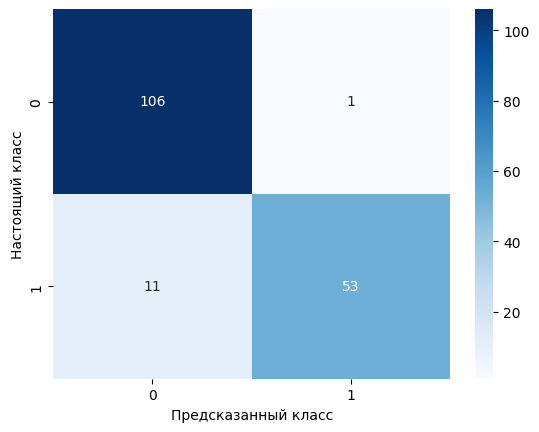

In [ ]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Предсказанный класс")
plt.ylabel("Настоящий класс")
plt.show()

##Шаг 8. Выводы

Сколько объектов каждого класса

Какие признаки лучше разделяют классы (по графикам pairplot)

Насколько точен KNN на тестовой выборке

Как интерпретировать результаты через confusion matrix